In [1]:
import numpy as np
import matplotlib.pyplot as plt
from upxo.pxtal.vortess2d import gtess2d

In [2]:
repr_prop = {'area': {'mean': {'val': 50, 'dev': 7.5},
                      'consider_boundary_grains': True}}
gset = gtess2d.from_seed_points(sp_input='gen', xbound=[0, 100],
                                ybound=[0, 100], sp_distr='random',
                                gr_tech='pds', smp_tech='bridson1',
                                lean='veryhigh', char_length=[4.5],
                                niter=10, ntrials=100, n_instances=2,
                                repr_prop=repr_prop, k_char_length_inc=0.05,
                                k_char_length_dec=0.05)
centroids = np.array([[cell.centroid.xy[0][0], cell.centroid.xy[1][0]]
                      for cell in gset.pxtals[1]])

Generating pxtal. Iteration 1
No. of seed points: 497
Generating pxtal. Iteration 2
No. of seed points: 500
Generating pxtal. Iteration 3
No. of seed points: 435
Generating pxtal. Iteration 4
No. of seed points: 426
Generating pxtal. Iteration 5
No. of seed points: 377
Generating pxtal. Iteration 6
No. of seed points: 333
Generating pxtal. Iteration 7
No. of seed points: 320
Generating pxtal. Iteration 8
No. of seed points: 304
Generating pxtal. Iteration 9
No. of seed points: 276
Generating pxtal. Iteration 10
No. of seed points: 267
Generating pxtal. Iteration 11
No. of seed points: 234
Generating pxtal. Iteration 12
No. of seed points: 217
Generating pxtal. Iteration 13
No. of seed points: 228
Generating pxtal. Iteration 14
No. of seed points: 196
----------------------------------------
Grain structure search converged in 13 iterations
Sample set parent found.
----
Target mean grain area: 50
Sample mean grain area: 51.020408
----
Input Char. length: [4.5]
Final Char. length: [7.2]


TypeError: 'MultiPolygon' object is not iterable

In [ ]:
from upxo.geoEntities.mulpoint2d import MPoint2d as mp2d
centroids = mp2d.from_coords(centroids)

I am in shapely
##########################
208
##########################
-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*
-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*


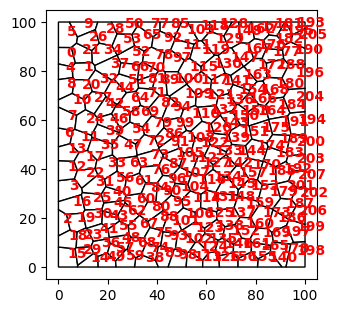

In [ ]:
from upxo.pxtal.polyxtal import vtpolyxtal2d as vtpxtal
vtgs = vtpxtal(gsgen_method='vt', vt_base_tool='shapely',
               point_method='mulpoints', mulpoint_object=centroids,
               xbound=[0, 100], ybound=[0, 100], vis_vtgs=True)

In [ ]:
elshape, elorder, algorithm = 'tri', 1, 6
from upxo.meshing.pxtalmesh_01 import geo_pxtal_mesh

In [ ]:
pxtal_mesh = geo_pxtal_mesh(mesher='pygmsh', pxtal=vtgs, level=0,
                            elshape=elshape, elorder=elorder,
                            algorithm=algorithm, elsize_global=[2., 2.5, 2.5],
                            optimize=True, sta=True, wtfs=True,
                            ff=['vtk', 'inp'], throw=False)

meshing pxtal.get_L0_ng()
----------------------------------------
PXTAL with 208 xtals: meshing success 
     Dimensionality = 2 
     Element order = 1 
     Algorithm = 6 
----------------------------------------


In [ ]:
vtgs.mesh = pxtal_mesh.mesh[3]

In [ ]:
filename = 'femesh'
fileformat = 'vtk'
mesh_filename = f'{filename}.{fileformat}'
vtgs.mesh.write(mesh_filename)
import pyvista as pv
grid = pv.read(mesh_filename)

In [ ]:
# Visualize the mesh quality field parameter
mqm = ['aspect_ratio', 'skew', 'min_angle', 'area']  # mesh_quality_measures

C:\Users\rg5749\AppData\Local\miniforge3\envs\shark\lib\site-packages\pyvista\jupyter\notebook.py:60: UserWarning: Failed to use notebook backend: 

Please install `ipyvtklink` to use this feature: https://github.com/Kitware/ipyvtklink

Falling back to a static output.
  warnings.warn(


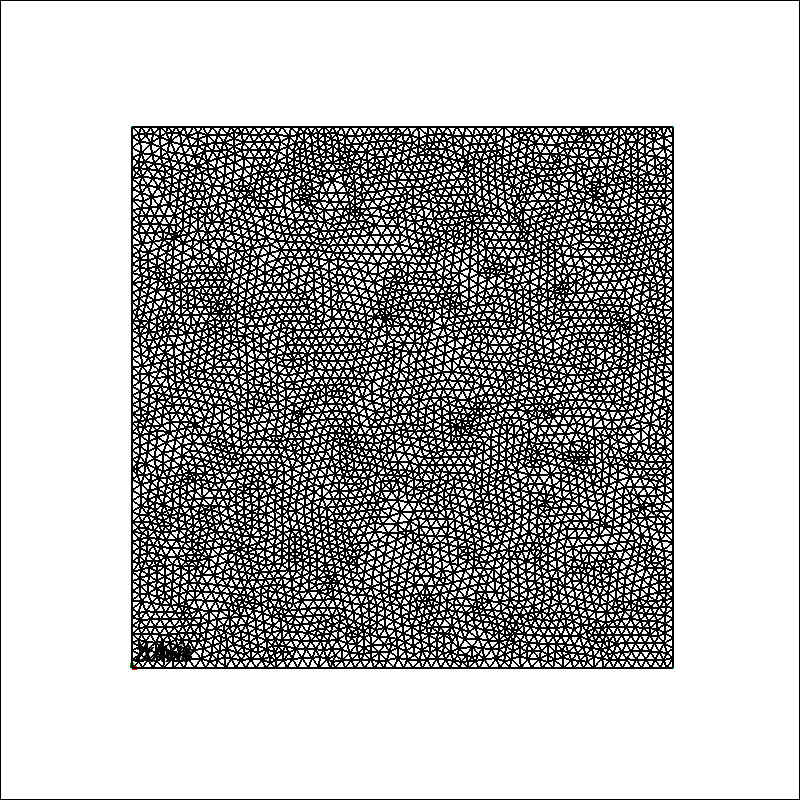

In [ ]:
# Visualize using pyvista
pxtal_mesh.vis_pyvista(data_to_vis='mesh > mesh > all',
                       rfia=True, grid=grid)

In [ ]:
# Calculate mesh quality
mqm_data, mqm_dataframe = pxtal_mesh.assess_pygmsh(grid=grid,
                                                   mesh_quality_measures=mqm,
                                                   elshape=elshape,
                                                   elorder=elorder,
                                                   algorithm=algorithm)

In [ ]:
clims = [[1.0, 2.5], [-1.0, 1.0], [0.0, 90.0],
         [0.0*mqm_dataframe['area'].max(),
          mqm_dataframe['area'].max()]]

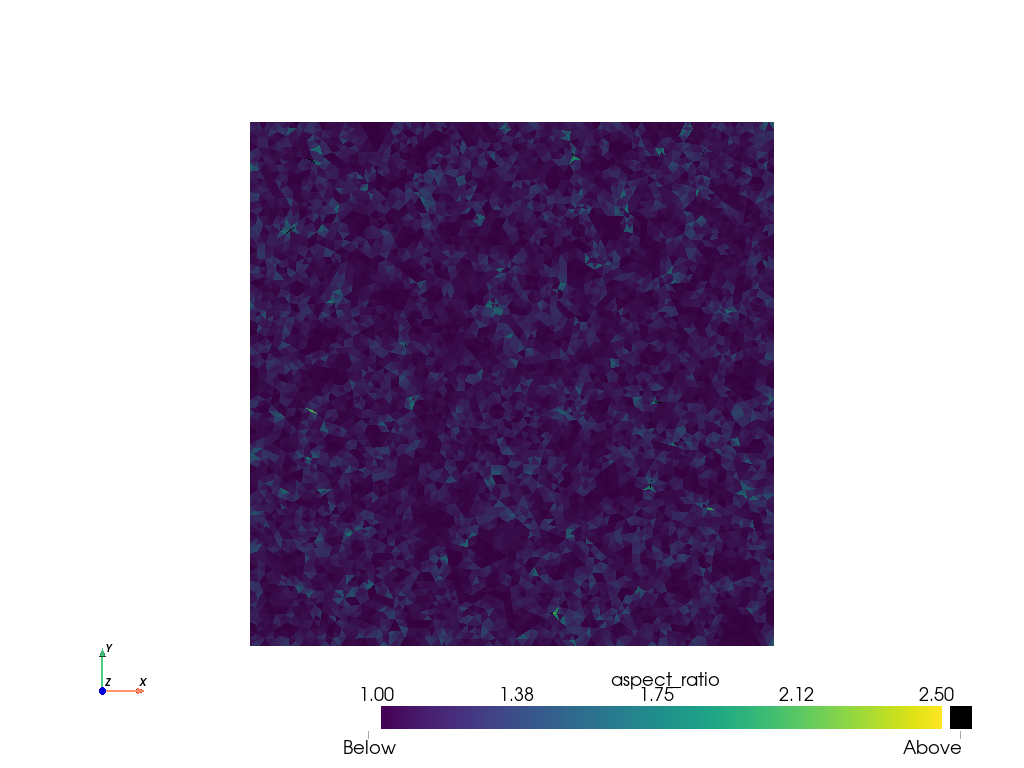

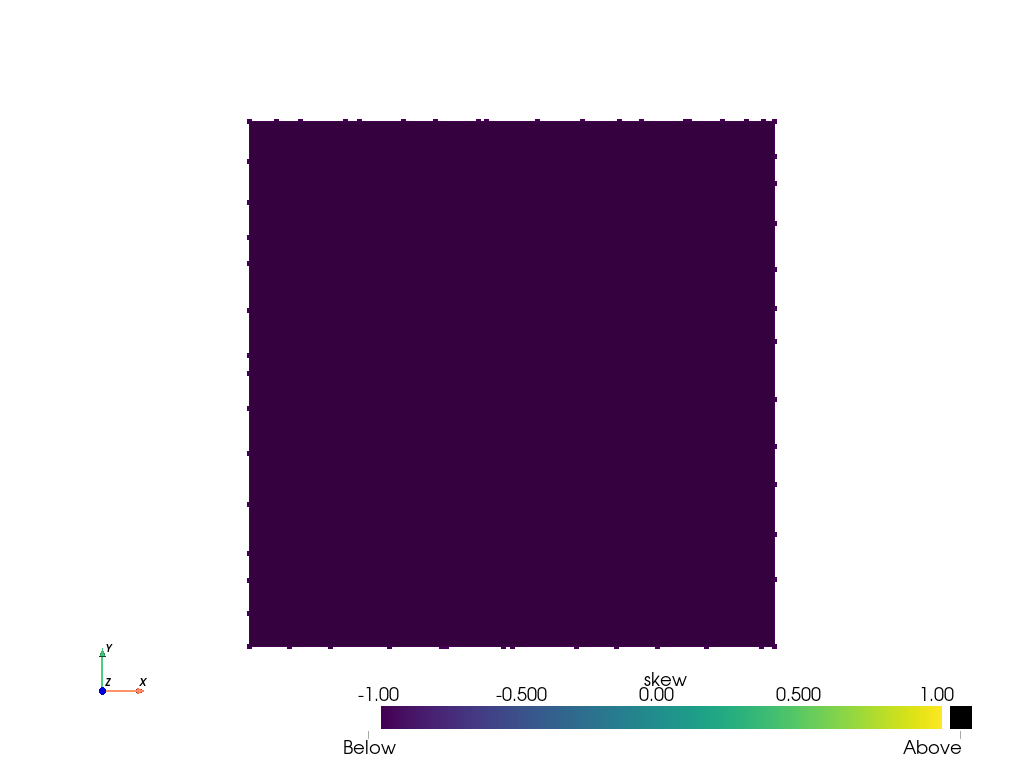

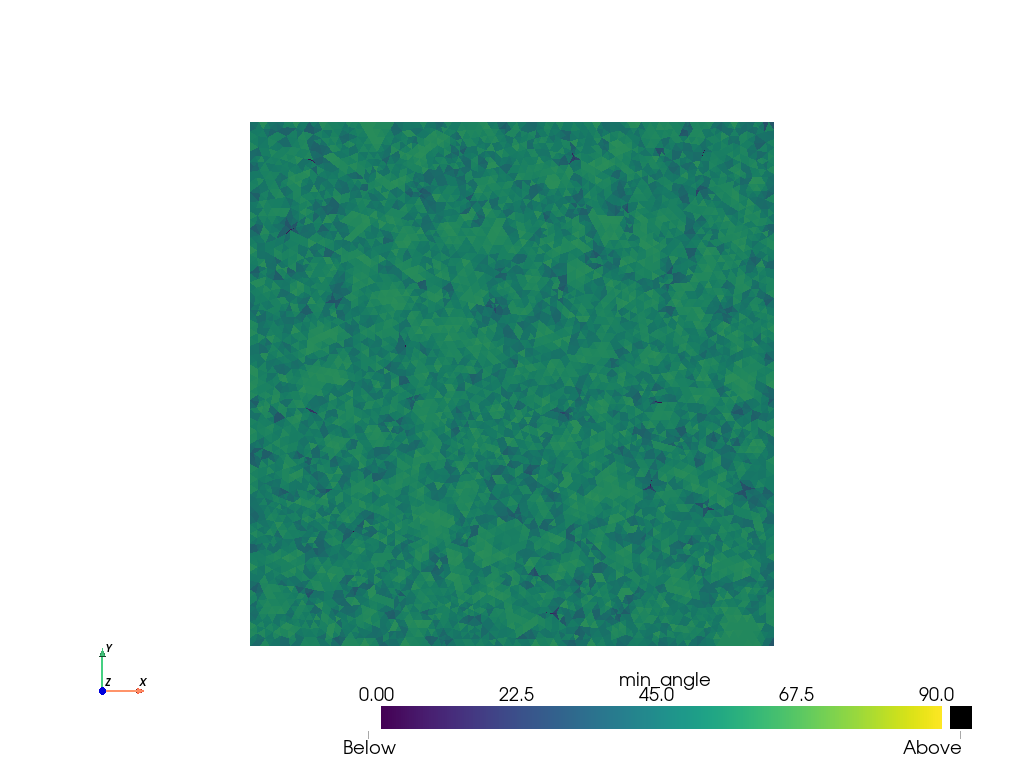

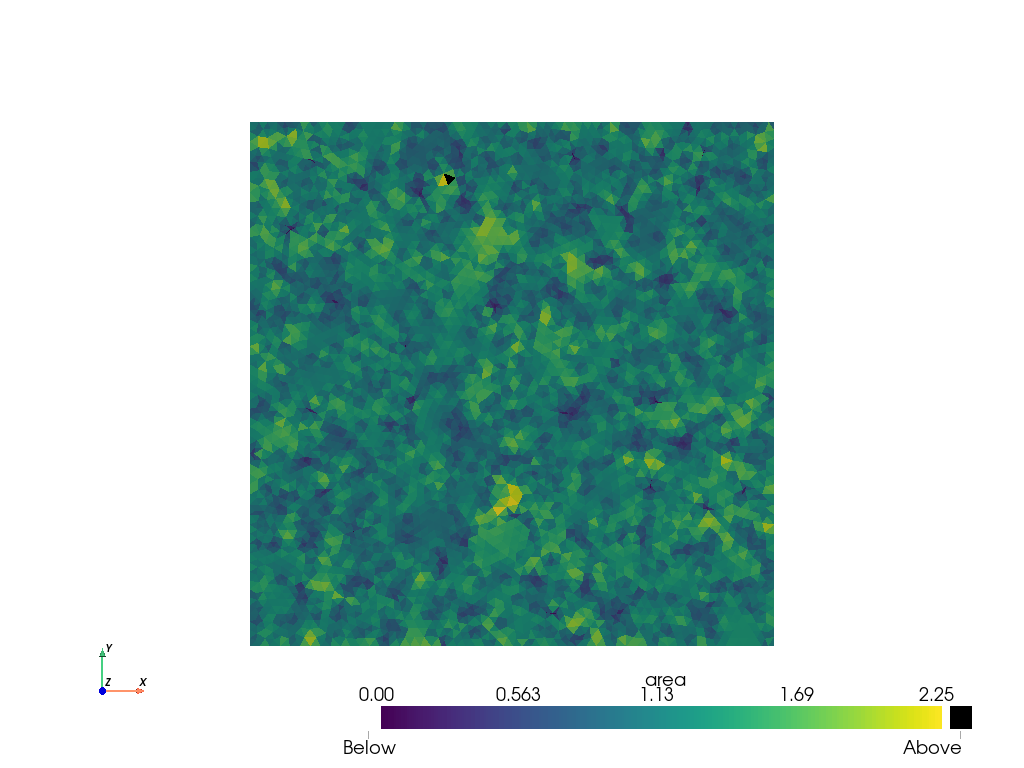

In [ ]:
pxtal_mesh.vis_pyvista(data_to_vis='mesh > quality > field',
                       mesh_qual_fields=mqm_data,
                       mesh_qual_field_vis_par={'mesh_quality_measures': mqm,
                                                'cpos': 'xy',
                                                'scalars': 'CellQuality',
                                                'show_edges': False,
                                                'cmap': 'viridis',
                                                'clims': clims,
                                                'below_color': 'white',
                                                'above_color': 'black',
                                                }
                       )

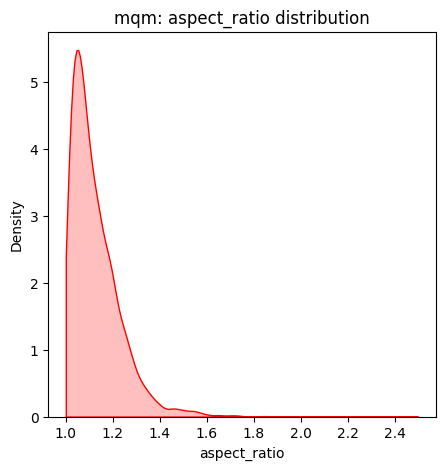

c:\development\m2matmod\upxo_packaged\upxo_private\src\upxo\meshing\pxtalmesh_01.py:666: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data = data[df_name],


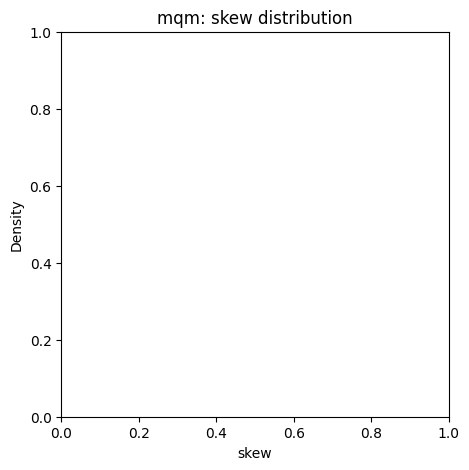

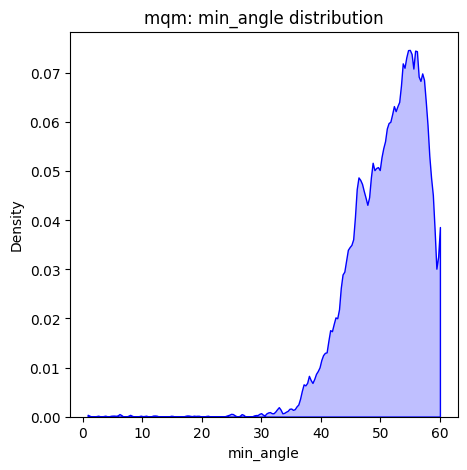

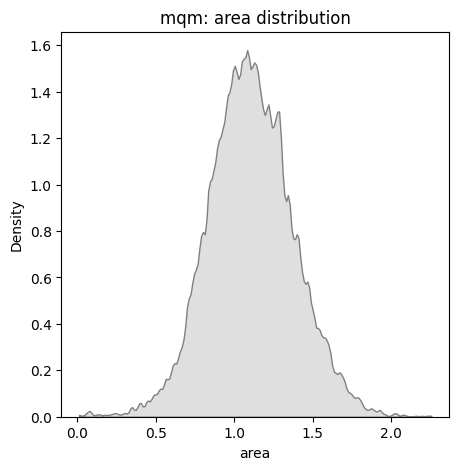

In [ ]:
# KDE- plot of data
band_widths = 4*[0.25]
colors = ['red', 'green', 'blue', 'gray']
pxtal_mesh.vis_kde(data=mqm_dataframe, datatype='pandas_df', df_names=mqm,
                   clips=clims, cumulative=False, band_widths=band_widths,
                   colors=colors)